# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
# Run this cell first if TensorFlow is not available in your notebook runtime.
# In Google Colab, TensorFlow is usually preinstalled.
import importlib.util
import sys

if importlib.util.find_spec("tensorflow") is None:
    print("TensorFlow is not installed in this environment.")
    print("Install it, then restart the kernel/runtime and run the notebook again:")
    print(f"{sys.executable} -m pip install tensorflow")
else:
    print("TensorFlow is already installed.")


TensorFlow is already installed.


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

 16310272/170498071 ━━━━━━━━━━━━━━━━━━━━ 3:42:38 87us/step

## 🖼️ Visualize Sample Images

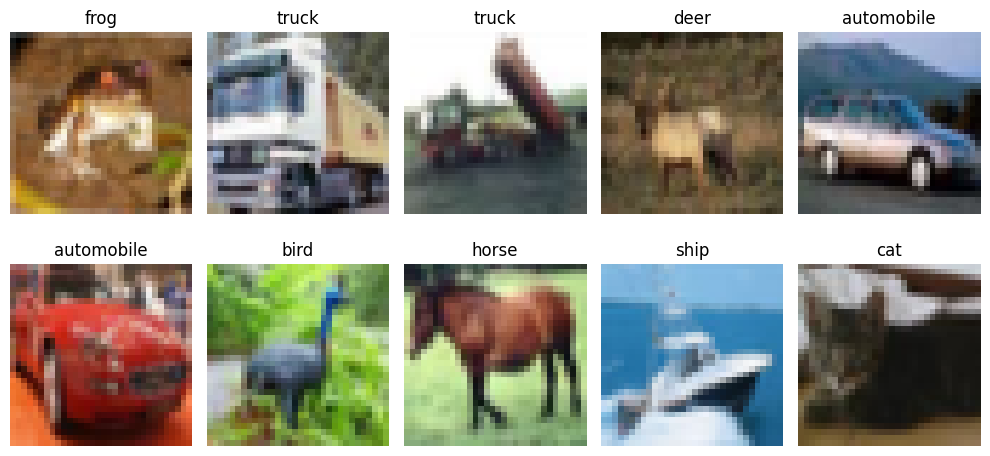

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.2694 - loss: 1.9943 - val_accuracy: 0.3374 - val_loss: 1.8665
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3115 - loss: 1.8772 - val_accuracy: 0.3406 - val_loss: 1.8015
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3281 - loss: 1.8335 - val_accuracy: 0.3774 - val_loss: 1.7621
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3444 - loss: 1.8005 - val_accuracy: 0.3694 - val_loss: 1.7463
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3528 - loss: 1.7735 - val_accuracy: 0.3904 - val_loss: 1.7382
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.3606 - loss: 1.7623 - val_accuracy: 0.3928 - val_loss: 1.7052
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.3645 - loss: 1.7407 - val_accuracy: 0.3924 - val_loss: 1.7186
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3710 - loss: 1.7259 - 

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4166 - loss: 1.6645
ANN Test Accuracy: 0.41659998893737793


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 120ms/step - accuracy: 0.4686 - loss: 1.4902 - val_accuracy: 0.3834 - val_loss: 1.7229
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 120ms/step - accuracy: 0.6118 - loss: 1.1129 - val_accuracy: 0.6236 - val_loss: 1.0813
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.6750 - loss: 0.9355 - val_accuracy: 0.6026 - val_loss: 1.1239
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7148 - loss: 0.8182 - val_accuracy: 0.6232 - val_loss: 1.1081
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.7474 - loss: 0.7225 - val_accuracy: 0.7088 - val_loss: 0.8446
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 84s 119ms/step - accuracy: 0.7751 - loss: 0.6447 - val_accuracy: 0.7518 - val_loss: 0.7365
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 121ms/step - accuracy: 0.7979 - loss: 0.5729 - val_accuracy: 0.7078 - val_loss: 0.9493
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 123ms/step - accuracy: 0.8192 - loss:

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6770 - loss: 1.2141
CNN Test Accuracy: 0.6769999861717224


## 📈 Compare Learning Curves

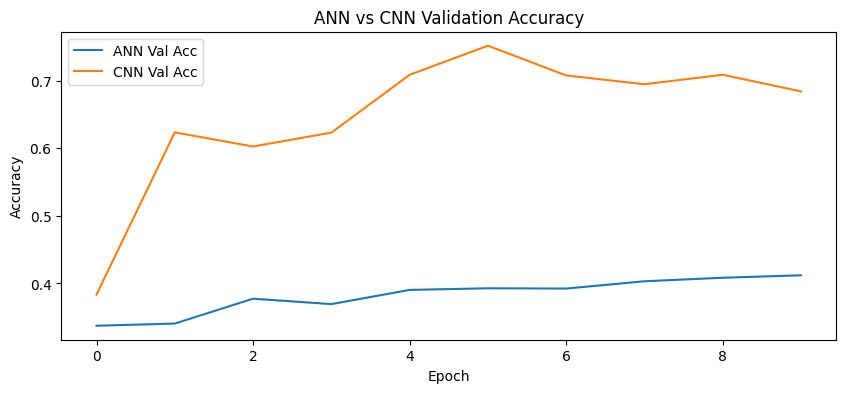

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4166
1,CNN,0.6770


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## Task 1: Increase ANN Layers

In [ ]:
ann_deep_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_deep_history = ann_deep_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

ann_deep_test_loss, ann_deep_test_acc = ann_deep_model.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", ann_deep_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 66ms/step - accuracy: 0.2247 - loss: 2.0680 - val_accuracy: 0.3086 - val_loss: 1.9224
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.2916 - loss: 1.9181 - val_accuracy: 0.3170 - val_loss: 1.8765
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3148 - loss: 1.8693 - val_accuracy: 0.3500 - val_loss: 1.8017
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.3273 - loss: 1.8403 - val_accuracy: 0.3688 - val_loss: 1.7844
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3347 - loss: 1.8154 - val_accuracy: 0.3798 - val_loss: 1.7281
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 45s 64ms/step - accuracy: 0.3448 - loss: 1.7909 - val_accuracy: 0.3766 - val_loss: 1.7576
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - accuracy: 0.3469 - loss: 1.7834 - val_accuracy: 0.3926 - val_loss: 1.7246
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.3520 - loss: 1.7753 - 

## Task 2: Scale CNN Filters (32 → 64 → 128)


In [ ]:
cnn_wide_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_wide_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_wide_history = cnn_wide_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

cnn_wide_test_loss, cnn_wide_test_acc = cnn_wide_model.evaluate(x_test_norm, y_test)
print("Wider CNN Test Accuracy:", cnn_wide_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 228s 320ms/step - accuracy: 0.4520 - loss: 1.5308 - val_accuracy: 0.5110 - val_loss: 1.3882
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 260s 317ms/step - accuracy: 0.6054 - loss: 1.1383 - val_accuracy: 0.6438 - val_loss: 1.0161
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 224s 318ms/step - accuracy: 0.6733 - loss: 0.9427 - val_accuracy: 0.6528 - val_loss: 1.0459
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 224s 318ms/step - accuracy: 0.7214 - loss: 0.8001 - val_accuracy: 0.7158 - val_loss: 0.8112
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 225s 319ms/step - accuracy: 0.7559 - loss: 0.7051 - val_accuracy: 0.6278 - val_loss: 1.1363
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 221s 314ms/step - accuracy: 0.7837 - loss: 0.6211 - val_accuracy: 0.6896 - val_loss: 0.9219
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 220s 313ms/step - accuracy: 0.8122 - loss: 0.5378 - val_accuracy: 0.7254 - val_loss: 0.8538
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 270s 324ms/step - accuracy: 0.8384 -

## Task 3: Increase Epochs to 20

In [ ]:
cnn_model_20ep = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_20ep.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_20ep_history = cnn_model_20ep.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn_20ep_test_loss, cnn_20ep_test_acc = cnn_model_20ep.evaluate(x_test_norm, y_test)
print("CNN (20 epochs) Test Accuracy:", cnn_20ep_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 123ms/step - accuracy: 0.4650 - loss: 1.4955 - val_accuracy: 0.5816 - val_loss: 1.2040
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 124ms/step - accuracy: 0.6100 - loss: 1.1295 - val_accuracy: 0.6420 - val_loss: 0.9966
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 85s 121ms/step - accuracy: 0.6686 - loss: 0.9552 - val_accuracy: 0.6272 - val_loss: 1.0643
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 125ms/step - accuracy: 0.7075 - loss: 0.8374 - val_accuracy: 0.6904 - val_loss: 0.8768
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 125ms/step - accuracy: 0.7413 - loss: 0.7423 - val_accuracy: 0.6762 - val_loss: 0.9469
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7674 - loss: 0.6705 - val_accuracy: 0.7060 - val_loss: 0.8855
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 90s 128ms/step - accuracy: 0.7927 - loss: 0.5935 - val_accuracy: 0.7026 - val_loss: 0.8718
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 124ms/step - accuracy: 0.8108 - los

## Task 4: Add EarlyStopping

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_model_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_es_history = cnn_model_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_test_loss, cnn_es_test_acc = cnn_model_es.evaluate(x_test_norm, y_test)
print("CNN (EarlyStopping) Test Accuracy:", cnn_es_test_acc)
print("Stopped at epoch:", len(cnn_es_history.history['loss']))

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 122ms/step - accuracy: 0.4534 - loss: 1.5302 - val_accuracy: 0.5286 - val_loss: 1.3192
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.5872 - loss: 1.1728 - val_accuracy: 0.6198 - val_loss: 1.0861
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 121ms/step - accuracy: 0.6527 - loss: 0.9962 - val_accuracy: 0.5970 - val_loss: 1.2384
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.7004 - loss: 0.8608 - val_accuracy: 0.6556 - val_loss: 1.0338
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 122ms/step - accuracy: 0.7344 - loss: 0.7731 - val_accuracy: 0.7058 - val_loss: 0.8686
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.7591 - loss: 0.6888 - val_accuracy: 0.6696 - val_loss: 1.0476
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 122ms/step - accuracy: 0.7824 - loss: 0.6179 - val_accuracy: 0.6998 - val_loss: 0.9369
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 122ms/step - accuracy: 0.8059 - loss

## Task 5: Run Data Augmentation Training

In [ ]:
early_stop_aug = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop_aug]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 68s 94ms/step - accuracy: 0.3604 - loss: 1.7635 - val_accuracy: 0.4540 - val_loss: 1.5179
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 64s 91ms/step - accuracy: 0.4511 - loss: 1.5217 - val_accuracy: 0.5180 - val_loss: 1.3207
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.4926 - loss: 1.4256 - val_accuracy: 0.5622 - val_loss: 1.2112
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5158 - loss: 1.3648 - val_accuracy: 0.5860 - val_loss: 1.1730
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 92ms/step - accuracy: 0.5288 - loss: 1.3259 - val_accuracy: 0.5908 - val_loss: 1.1733
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 94ms/step - accuracy: 0.5466 - loss: 1.2849 - val_accuracy: 0.5522 - val_loss: 1.2966
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 93ms/step - accuracy: 0.5553 - loss: 1.2574 - val_accuracy: 0.6066 - val_loss: 1.1158
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.5672 - loss: 1.2291 - 

# 📊 Updated Final Comparison Table (All Variants)

In [ ]:
comparison_all = pd.DataFrame({
    "Model": [
        "ANN (baseline)",
        "CNN (baseline, 10 epochs)",
        "ANN (deeper, Task 1)",
        "CNN (wider filters 64-128-256, Task 2)",
        "CNN (20 epochs, Task 3)",
        "CNN (EarlyStopping, Task 4)",
        "CNN (Data Augmentation, Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_deep_test_acc,
        cnn_wide_test_acc,
        cnn_20ep_test_acc,
        cnn_es_test_acc,
        aug_test_acc
    ]
})
comparison_all.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)

,Model,Test Accuracy
0,"CNN (wider filters 64-128-256, Task 2)",0.7322
1,"CNN (20 epochs, Task 3)",0.7136
2,"CNN (EarlyStopping, Task 4)",0.6958
3,"CNN (baseline, 10 epochs)",0.6770
4,"CNN (Data Augmentation, Task 5)",0.6563
5,ANN (baseline),0.4166
6,"ANN (deeper, Task 1)",0.4078


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**